# 대사증후군 AI - 시계열 더미데이터 생성

## 프로젝트 개요
국민건강보험공단 13년치(2012~2024) 건강검진 데이터 기반
체중 감량 시 대사증후군 5대 지표 변화 예측 모델

## 구성
- STEP 0: 원시데이터 로드
- STEP 1: 전처리 (smoke/drink 이진화 + 이상치 제거)
- STEP 2: 의학 계수 테이블 정의
- STEP 3: 시계열 더미데이터 생성 (82만명 × 10단계 = 820만 행)
- STEP 4: 더미데이터 검증
- STEP 5: 피처 정의 및 학습/검증 분리
- STEP 6: XGBoost 학습
- STEP 7: 모델 저장
- STEP 8: 시뮬레이터 함수 정의
- STEP 9: 시뮬레이터 테스트
- STEP 10: 원시데이터 교차검증

## 컬럼 정의
- smoke: 0=비흡연/금연, 1=현재흡연
- drink: 0=비음주, 1=음주
- gender: 1=남, 2=여
- age_code: 7=30대초 ~ 12=50대후


In [1]:
# STEP 0. 원시데이터 로드

import pandas as pd   # 표(데이터프레임) 처리 전문 라이브러리. 엑셀처럼 행/열로 데이터 다룸
import numpy as np    # 수치 계산 전문 라이브러리. 배열 연산, 수학 계산에 사용
import os             # 파일 경로 조합 등 운영체제 기능
import gc             # 메모리 강제 정리 도구. 큰 변수 삭제 후 RAM 확보할 때 사용

path = r'C:\Users\smhrd1\Desktop\13년치'

file_names = [f"국민건강보험공단_건강검진정보_{year}.CSV" for year in range(2012, 2025)]

raw_to_standard = {
    '성별코드': 'gender', '성별': 'gender',
    '연령대코드(5세단위)': 'age_code',
    '신장(5cm단위)': 'height', '신장(5Cm단위)': 'height',
    '체중(5kg단위)': 'weight', '체중(5Kg단위)': 'weight',
    '허리둘레': 'waist',
    '수축기혈압': 'sbp',       # Systolic Blood Pressure
    '이완기혈압': 'dbp',       # Diastolic Blood Pressure
    '식전혈당(공복혈당)': 'bs', # Blood Sugar
    '트리글리세라이드': 'tg',   # Triglyceride (중성지방)
    'HDL콜레스테롤': 'hdl',
    '흡연상태': 'smoke',
    '음주여부': 'drink',
}

all_dfs = []  # 13개 파일을 담아둘 빈 리스트

for f_name in file_names:
    full_path = os.path.join(path, f_name)
    try:
        df = pd.read_csv(full_path, encoding='cp949', low_memory=False)

        df.columns = df.columns.str.replace(' ', '').str.lower()

        lower_map = {k.lower(): v for k, v in raw_to_standard.items()}

        existing_cols = [c for c in df.columns if c in lower_map]
        df_f = df[existing_cols].rename(columns=lower_map)

        del df; gc.collect()

        for col in ['smoke', 'drink', 'age_code', 'height', 'weight']:
            if col not in df_f.columns:
                df_f[col] = pd.NA

        df_f = df_f[(df_f['age_code'] >= 7) & (df_f['age_code'] <= 12)]

        df_f = df_f[df_f['height'] >= 140]

        df_f['bmi'] = (df_f['weight'] / ((df_f['height'] / 100) ** 2))

        df_f['year'] = f_name.split('_')[-1].split('.')[0]

        all_dfs.append(df_f)  # 리스트에 추가
        print(f"\u2705 {f_name}: {len(df_f):,}\ud589")

    except Exception as e:
        print(f"\u274c {f_name}: {e}")

raw_df = pd.concat(all_dfs, ignore_index=True)

del all_dfs; gc.collect()
print(f"\n\U0001f5c2  \ud1b5\ud569 \uc644\ub8cc: {len(raw_df):,}\ud589")


✅ 국민건강보험공단_건강검진정보_2012.CSV: 448,944행
✅ 국민건강보험공단_건강검진정보_2013.CSV: 446,923행
✅ 국민건강보험공단_건강검진정보_2014.CSV: 678,811행
✅ 국민건강보험공단_건강검진정보_2015.CSV: 674,445행
✅ 국민건강보험공단_건강검진정보_2016.CSV: 660,910행
✅ 국민건강보험공단_건강검진정보_2017.CSV: 656,847행
✅ 국민건강보험공단_건강검진정보_2018.CSV: 645,291행
✅ 국민건강보험공단_건강검진정보_2019.CSV: 627,562행
✅ 국민건강보험공단_건강검진정보_2020.CSV: 613,865행
✅ 국민건강보험공단_건강검진정보_2021.CSV: 608,502행
✅ 국민건강보험공단_건강검진정보_2022.CSV: 602,838행
✅ 국민건강보험공단_건강검진정보_2023.CSV: 600,023행
✅ 국민건강보험공단_건강검진정보_2024.CSV: 595,262행

🗂  통합 완료: 7,860,223행


In [2]:
# STEP 1. smoke/drink 전처리 + 이상치 제거

def normalize_smoke(val):
    if pd.isna(val):    # 값이 비어있으면(NaN) 비흡연으로 처리
        return 0
    s = str(val).strip().upper()  # 문자열로 변환, 앞뒤 공백 제거, 대문자 통일
    if s in ('Y', 'YES'):
        return 1  # Y = 현재흡연 (일부 연도 표기)
    if s in ('N', 'NO'):
        return 0  # N = 비흡연
    try:
        v = int(float(s))
        if v == 3:
            return 1  # 3 = 현재흡연 → 1
        return 0      # 1=비흡연, 2=금연 → 0 (금연도 패널티 없음)
    except:
        pass
    return 0  # 그 외 모든 경우 → 비흡연으로 처리

def normalize_drink(val):
    if pd.isna(val):
        return 0  # 결측 → 비음주
    s = str(val).strip().upper()
    if s in ('Y', 'YES', '1'):
        return 1  # 음주
    if s in ('N', 'NO', '0'):
        return 0  # 비음주
    try:
        v = int(float(s))
        return 1 if v >= 1 else 0
    except:
        pass
    return 0

raw_df['smoke'] = raw_df['smoke'].apply(normalize_smoke).astype('int8')
raw_df['drink'] = raw_df['drink'].apply(normalize_drink).astype('int8')

essential = ['bs','sbp','dbp','tg','hdl','waist','bmi','weight']
raw_df.dropna(subset=essential, inplace=True)

raw_df = raw_df[
    (raw_df['sbp']    >  70) & (raw_df['sbp']    < 250) &
    (raw_df['dbp']    >  40) & (raw_df['dbp']    < 150) &
    (raw_df['bs']     >  50) & (raw_df['bs']     < 400) &
    (raw_df['waist']  >  40) & (raw_df['waist']  < 150) &
    (raw_df['tg']     >   5) & (raw_df['tg']     < 500) &
    (raw_df['hdl']    >   5) & (raw_df['hdl']    < 200) &
    (raw_df['bmi']    >  10) & (raw_df['bmi']    <  60) &
    (raw_df['weight'] >  30) & (raw_df['weight'] < 160)
]

print(f'\u2705 \uc774\uc0c1\uce58 \uc81c\uac70 \ud6c4 \uc6d0\uc2dc\ub370\uc774\ud130: {len(raw_df):,}\ud589')
print(f'\nsmoke \ubd84\ud3ec:')
print(raw_df['smoke'].value_counts().sort_index().rename({0:'\ube44\ud761\uc5f0/\uae08\uc5f0',1:'\ud604\uc7ac\ud761\uc5f0'}))
print(f'\ndrink \ubd84\ud3ec:')
print(raw_df['drink'].value_counts().sort_index().rename({0:'\ube44\uc74c\uc8fc',1:'\uc74c\uc8fc'}))


✅ 이상치 제거 후 원시데이터: 4,847,486행

smoke 분포:
smoke
비흡연/금연    3762397
현재흡연      1085089
Name: count, dtype: int64

drink 분포:
drink
비음주    2602066
음주     2245420
Name: count, dtype: int64


In [3]:
# STEP 2. 의학 계수 테이블 정의

COEF = {
    # noise_std: 신호 대비 55~65% 수준 → 목표 R² 0.70~0.73
    (1, False): dict(
        sbp     =(1.05, 2.5),  # 수축기혈압: 1kg당 1.05mmHg 감소 / 개인차 std=2.8
        dbp     =(0.72, 1.8),  # 이완기혈압: 1kg당 0.72mmHg 감소 / 개인차 std=2.0
        waist   =(0.88, 2.5),  # 허리둘레:   1kg당 0.88cm 감소   / 개인차 std=2.5
        bs      =(0.68, 1.9),  # 공복혈당:   1kg당 0.68mg/dL 감소 / 개인차 std=2.8
        hdl     =(0.19, 0.55), # HDL:        1kg당 0.19mg/dL 상승 / 개인차 std=0.55
        tg_rate =(1.15, 0.05)  # 중성지방:   비율 방식 계수 / 개인차 std=0.08
    ),
    (1, True): dict(
        sbp     =(1.15, 2.8),
        dbp     =(0.80, 2.0),
        waist   =(0.95, 2.8),
        bs      =(0.88, 2.2),
        hdl     =(0.22, 0.60),
        tg_rate =(1.32, 0.06)
    ),
    (2, False): dict(
        sbp     =(0.95, 2.2),
        dbp     =(0.65, 1.6),
        waist   =(0.82, 2.2),
        bs      =(0.58, 1.7),
        hdl     =(0.21, 0.50),
        tg_rate =(1.08, 0.04)
    ),
    (2, True): dict(
        sbp     =(1.05, 2.5),
        dbp     =(0.73, 1.8),
        waist   =(0.92, 2.5),
        bs      =(0.78, 2.0),
        hdl     =(0.26, 0.55),
        tg_rate =(1.22, 0.05)
    ),
}

SMOKE_PENALTY = dict(
    sbp=0.25,    # 수축기혈압 개선 25% 감소 (대한고혈압학회 근거)
    dbp=0.25,    # 이완기혈압 개선 25% 감소
    waist=0.15,  # 허리둘레 개선 15% 감소
    bs=0.25      # 공복혈당 개선 25% 감소 (대한당뇨병학회 근거)
)

DRINK_PENALTY = dict(
    tg_rate=0.30,  # 중성지방 개선 30% 감소
    hdl=0.20       # HDL 상승 20% 감소
)

print('\u2705 \uc758\ud559 \uacc4\uc218 \ud14c\uc774\ube14 \uc815\uc758 \uc644\ub8cc')


✅ 의학 계수 테이블 정의 완료


In [4]:
# STEP 3. 시계열 더미데이터 생성 함수 (BMI 구간별 최대 감량 차등 적용)

def get_max_loss_kg(bmi):
    """
    BMI 구간별 현실적인 최대 감량 설정 (9단계 세분화)
    경계값에서 급격한 변화 방지 → 슬라이더 UX 부드럽게
    """
    if bmi < 22:   return 8    # 저체중/정상 하단
    elif bmi < 25: return 10   # 정상체중
    elif bmi < 27: return 12   # 과체중 초입
    elif bmi < 30: return 15   # 과체중
    elif bmi < 32: return 20   # 비만1 초입
    elif bmi < 35: return 25   # 비만1
    elif bmi < 38: return 30   # 비만2 초입
    elif bmi < 40: return 35   # 비만2
    else:          return 50   # 고도비만

def generate_timeseries_dummy(raw_df, n_persons=820_000, random_state=42):
    """
    BMI 구간별 최대 감량을 다르게 적용한 시계열 더미 생성
    개인별 BMI로 max_loss 계산 후 그룹 최빈값 적용
    """
    rng    = np.random.default_rng(random_state)
    raw_df = raw_df.reset_index(drop=True)

    groups      = [(g,a,o) for g in [1,2]
                            for a in [7,8,9,10,11,12]
                            for o in [False,True]]
    n_per_group = n_persons // len(groups)
    print(f"📊 그룹: {len(groups)}개 / 그룹당: {n_per_group:,}명 / 총: {n_per_group*len(groups):,}명")

    all_chunks        = []
    person_id_counter = 0

    for gender, age_code, is_obese in groups:
        bmi_cond = (raw_df['bmi'] >= 25) if is_obese else (raw_df['bmi'] < 25)
        pool = raw_df[(raw_df['gender']==gender)&
                      (raw_df['age_code']==age_code)&bmi_cond]
        if len(pool) < 30: pool = raw_df[(raw_df['gender']==gender)&bmi_cond]
        if len(pool) < 30: pool = raw_df[raw_df['gender']==gender]
        if len(pool) < 30: pool = raw_df

        n    = n_per_group
        base = pool.sample(n=n, replace=(len(pool)<n),
                           random_state=int(rng.integers(0,99999))
                          ).reset_index(drop=True)

        g_arr     = base['gender'].values.astype(np.int8)
        a_arr     = base['age_code'].values.astype(np.int8)
        h_arr     = base['height'].values.astype(np.float32)
        smoke_arr = base['smoke'].values.astype(np.float32)
        drink_arr = base['drink'].values.astype(np.float32)
        w0        = base['weight'].values.astype(np.float32)
        waist0    = base['waist'].values.astype(np.float32)
        sbp0      = base['sbp'].values.astype(np.float32)
        dbp0      = base['dbp'].values.astype(np.float32)
        bs0       = base['bs'].values.astype(np.float32)
        tg0       = base['tg'].values.astype(np.float32)
        hdl0      = base['hdl'].values.astype(np.float32)

        # [문제1,2 수정] 개인별 BMI 계산 후 최빈값으로 max_loss 결정
        # 기존: 그룹 평균 BMI 1개로 결정 → 대표성 부족
        # 수정: 개인별 BMI → 개인별 max_loss → 그룹 최빈값
        if 'bmi' in base.columns:
            bmi_arr = base['bmi'].values.astype(np.float32)
        else:
            # bmi 컬럼 없을 때 개인별로 정확하게 계산
            bmi_arr = w0 / ((h_arr / 100) ** 2)

        max_losses  = np.array([get_max_loss_kg(float(b)) for b in bmi_arr], dtype=np.int16)
        max_loss_kg = int(np.bincount(max_losses).argmax())  # 최빈값

        is_cur_smoker = (smoke_arr == 1).astype(np.float32)
        is_drinker    = (drink_arr == 1).astype(np.float32)
        c = COEF[(gender, is_obese)]

        for step in range(1, max_loss_kg + 1):
            w_diff    = np.float32(step)
            w_cur     = np.maximum(w0 - w_diff, 45.0)
            act_diff  = w0 - w_cur
            loss_rate = act_diff / np.maximum(w0, 1.0)

            sp_bp    = 1.0 - is_cur_smoker * SMOKE_PENALTY['sbp']
            sp_waist = 1.0 - is_cur_smoker * SMOKE_PENALTY['waist']
            sp_bs    = 1.0 - is_cur_smoker * SMOKE_PENALTY['bs']
            dp_tg    = 1.0 - is_drinker    * DRINK_PENALTY['tg_rate']
            dp_hdl   = 1.0 - is_drinker    * DRINK_PENALTY['hdl']

            def N(std): return rng.normal(0, std, n).astype(np.float32)

            # 허리둘레: 최소 0.5cm/kg 감소 보장
            waist_raw   = -(act_diff * c['waist'][0] * sp_waist) + N(c['waist'][1])
            waist_min   = -(act_diff * 0.5)
            delta_waist = np.minimum(waist_raw, waist_min)

            delta_sbp = -(act_diff * c['sbp'][0] * sp_bp)  + N(c['sbp'][1])
            delta_dbp = -(act_diff * c['dbp'][0] * sp_bp)  + N(c['dbp'][1])
            delta_bs  = -(act_diff * c['bs'][0]  * sp_bs)  + N(c['bs'][1])
            delta_hdl =  (act_diff * c['hdl'][0] * dp_hdl) + N(c['hdl'][1])
            delta_tg  = -(tg0 * loss_rate * c['tg_rate'][0] * dp_tg) + \
                         N(float(np.mean(tg0 * c['tg_rate'][1])))

            waist_post = np.clip(waist0 + delta_waist, 40, 150)
            sbp_post   = np.clip(sbp0   + delta_sbp,   70, 250)
            dbp_post   = np.clip(dbp0   + delta_dbp,   40, 150)
            bs_post    = np.clip(bs0    + delta_bs,     50, 400)
            tg_post    = np.clip(tg0    + delta_tg,      5, 500)
            hdl_post   = np.clip(hdl0   + delta_hdl,     5, 200)

            chunk = pd.DataFrame({
                'person_id':   np.arange(person_id_counter,
                                         person_id_counter+n, dtype=np.int32),
                # [문제3 수정] int8 → int16 (최대 50단계까지 안전하게 저장)
                'step':        np.full(n, step, dtype=np.int16),
                'gender':      g_arr,   'age_code': a_arr, 'height': h_arr,
                'smoke':       smoke_arr, 'drink': drink_arr,
                'weight_pre':  w0,      'weight_diff': act_diff,
                'weight_cur':  w_cur,
                'waist_pre':   waist0,  'sbp_pre': sbp0, 'dbp_pre': dbp0,
                'bs_pre':      bs0,     'tg_pre':  tg0,  'hdl_pre': hdl0,
                'delta_waist': (waist_post - waist0).astype(np.float32),
                'delta_sbp':   (sbp_post   - sbp0 ).astype(np.float32),
                'delta_dbp':   (dbp_post   - dbp0 ).astype(np.float32),
                'delta_bs':    (bs_post    - bs0  ).astype(np.float32),
                'delta_tg':    (tg_post    - tg0  ).astype(np.float32),
                'delta_hdl':   (hdl_post   - hdl0 ).astype(np.float32),
            })
            all_chunks.append(chunk)

        person_id_counter += n

    df_dummy = pd.concat(all_chunks, ignore_index=True)
    print(f"\n✅ 더미 생성 완료: {len(df_dummy):,}행")
    print(f"   BMI 구간별 최대 감량: <22→8kg / 22-25→10kg / 25-27→12kg / 27-30→15kg")
    print(f"   30-32→20kg / 32-35→25kg / 35-38→30kg / 38-40→35kg / 40+→50kg")
    return df_dummy

print("🧬 시계열 더미 생성 시작 (BMI 9구간 세분화)...")
df_dummy = generate_timeseries_dummy(raw_df, n_persons=820_000)
gc.collect()


🧬 시계열 더미 생성 시작 (BMI 9구간 세분화)...
📊 그룹: 24개 / 그룹당: 34,166명 / 총: 819,984명

✅ 더미 생성 완료: 9,737,310행
   BMI 구간별 최대 감량: <22→8kg / 22-25→10kg / 25-27→12kg / 27-30→15kg
   30-32→20kg / 32-35→25kg / 35-38→30kg / 38-40→35kg / 40+→50kg


0

In [5]:
# STEP 4. 더미데이터 검증

print('=== [\uac80\uc99d1] \ub2e8\uacc4\ubcc4 \ud3c9\uade0 \u0394 (\ub2e8\uc870\uc99d\uac00 \ud655\uc778) ===')
verify = df_dummy.groupby('step')[
    ['delta_waist','delta_sbp','delta_dbp','delta_bs','delta_tg','delta_hdl']
].mean().round(2)
print(verify)

print('\n=== [\uac80\uc99d2] \ud761\uc5f0 \uc5ec\ubd80\ubcc4 \u0394sbp (step=5 \uae30\uc900) ===')
smoke_chk = df_dummy[df_dummy['step']==5].groupby('smoke')['delta_sbp'].mean().round(2)
print(smoke_chk.rename({0:'\ube44\ud761\uc5f0/\uae08\uc5f0',1:'\ud604\uc7ac\ud761\uc5f0'}))
print('  \u2192 \ud604\uc7ac\ud761\uc5f0(1) \uac1c\uc120\ud3ed\uc774 \ube44\ud761\uc5f0/\uae08\uc5f0(0)\ubcf4\ub2e4 \uc791\uc544\uc57c \uc815\uc0c1 \u2705')

print('\n=== [\uac80\uc99d3] \uc74c\uc8fc \uc5ec\ubd80\ubcc4 \u0394tg (step=5 \uae30\uc900) ===')
drink_chk = df_dummy[df_dummy['step']==5].groupby('drink')['delta_tg'].mean().round(2)
print(drink_chk.rename({0:'\ube44\uc74c\uc8fc',1:'\uc74c\uc8fc'}))
print('  \u2192 \uc74c\uc8fc(1)\uac00 \ube44\uc74c\uc8fc(0)\ubcf4\ub2e4 \uac1c\uc120\ud3ed \uc791\uc544\uc57c \uc815\uc0c1 \u2705')

print('\n=== [\uac80\uc99d4] smoke \uace0\uc720\uac12 \ud655\uc778 (0/1\ub9cc \uc788\uc5b4\uc57c \uc815\uc0c1) ===')
print(df_dummy['smoke'].value_counts().sort_index()
      .rename({0:'\ube44\ud761\uc5f0/\uae08\uc5f0',1:'\ud604\uc7ac\ud761\uc5f0'}))
print('\n=== [\uac80\uc99d5] drink \uace0\uc720\uac12 \ud655\uc778 (0/1\ub9cc \uc788\uc5b4\uc57c \uc815\uc0c1) ===')
print(df_dummy['drink'].value_counts().sort_index()
      .rename({0:'\ube44\uc74c\uc8fc',1:'\uc74c\uc8fc'}))


=== [검증1] 단계별 평균 Δ (단조증가 확인) ===
      delta_waist  delta_sbp  delta_dbp  delta_bs   delta_tg  delta_hdl
step                                                                   
1           -1.63      -0.91      -0.63     -0.64  -1.850000       0.18
2           -2.32      -1.87      -1.29     -1.31  -3.850000       0.38
3           -3.03      -2.81      -1.95     -1.97  -5.820000       0.57
4           -3.75      -3.78      -2.60     -2.64  -7.800000       0.76
5           -4.49      -4.72      -3.26     -3.30  -9.770000       0.95
6           -5.18      -5.60      -3.87     -3.93 -11.590000       1.13
7           -5.89      -6.49      -4.48     -4.54 -13.400000       1.30
8           -6.62      -7.36      -5.09     -5.16 -15.240000       1.48
9           -7.62      -8.57      -5.93     -6.09 -18.020000       1.72
10          -8.40      -9.50      -6.57     -6.75 -19.980000       1.91
11          -9.98     -11.42      -7.94     -8.61 -24.520000       2.39
12         -10.85     -12.43   

In [6]:
# STEP 5. 피처(입력값) 정의 및 학습/검증 데이터 분리

from sklearn.model_selection import train_test_split  # 데이터를 학습/검증 세트로 나눔
from xgboost import XGBRegressor                       # XGBoost 회귀 모델
from sklearn.metrics import mean_absolute_error, r2_score  # 모델 성능 평가 지표

X_features = [
    'gender',      # 성별 (1=남, 2=여)
    'age_code',    # 연령대 (7=30대초반 ~ 12=50대후반)
    'height',      # 키 (cm)
    'smoke',       # 흡연 (0=비흡연/금연, 1=현재흡연)
    'drink',       # 음주 (0=비음주, 1=음주)
    'weight_pre',  # 현재 체중 (kg)
    'weight_diff', # 감량 목표량 = 현재체중 - 목표체중 (kg)
    'waist_pre',   # 현재 허리둘레 (cm)
    'sbp_pre',     # 현재 수축기혈압 (mmHg)
    'dbp_pre',     # 현재 이완기혈압 (mmHg)
    'bs_pre',      # 현재 공복혈당 (mg/dL)
    'tg_pre',      # 현재 중성지방 (mg/dL)
    'hdl_pre',     # 현재 HDL 콜레스테롤 (mg/dL)
]

target_cols = [
    'delta_waist',  # 허리둘레 변화량
    'delta_sbp',    # 수축기혈압 변화량
    'delta_dbp',    # 이완기혈압 변화량
    'delta_bs',     # 공복혈당 변화량
    'delta_tg',     # 중성지방 변화량
    'delta_hdl',    # HDL 변화량
]

for col in X_features + target_cols:
    df_dummy[col] = pd.to_numeric(df_dummy[col], errors='coerce').fillna(0).astype('float32')

X = df_dummy[X_features]
y = df_dummy[target_cols]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\U0001f4e6 \ud559\uc2b5: {len(X_train):,}\ud589 / \uac80\uc99d: {len(X_val):,}\ud589')
print(f'   \ud53c\uc798 {len(X_features)}\uac1c: \uac1c\uc778\ud2b9\uc131 7\uac1c + \ud604\uc7ac \uac74\uac15\uc218\uce58 6\uac1c')


📦 학습: 7,789,848행 / 검증: 1,947,462행
   피잘 13개: 개인특성 7개 + 현재 건강수치 6개


In [7]:
# STEP 6. XGBoost 모델 학습

models  = {}  # 6개 지표 모델을 저장할 딕셔너리
results = {}  # 6개 지표 성능 점수를 저장할 딕셔너리

target_labels = {
    'delta_waist':'허리둘레 \u0394(cm)', 'delta_sbp':'수축기혈압 \u0394(mmHg)',
    'delta_dbp':'이완기혈압 \u0394(mmHg)', 'delta_bs':'공복혈당 \u0394(mg/dL)',
    'delta_tg':'중성지방 \u0394(mg/dL)', 'delta_hdl':'HDL \u0394(mg/dL)',
}

print(f'\U0001f680 XGBoost \ud559\uc2b5 \uc2dc\uc791 ({len(X_train):,}\uac74)...\n')

for col in target_cols:
    model = XGBRegressor(
        n_estimators=300,       # 트리 300개 생성 (많을수록 정교하지만 느림)
        learning_rate=0.05,     # 각 트리의 학습 보폭 (작을수록 신중하게 학습)
        max_depth=6,            # 트리 1개의 최대 깊이 (깊을수록 복잡한 패턴 학습)
        min_child_weight=50,    # 한 잎사귀 노드에 최소 50개 데이터 필요 → 과적합 방지
        subsample=0.8,          # 각 트리 학습 시 전체 데이터의 80%만 사용 → 과적합 방지
        colsample_bytree=0.8,   # 각 트리 학습 시 전체 피처의 80%만 사용 → 과적합 방지
        tree_method='hist',     # 빠른 히스토그램 기반 학습 방법
        device='cuda',          # GPU 사용 (없으면 'cpu'로 변경)
        random_state=42         # 재현 가능한 결과를 위한 랜덤 시드 고정
    )

    model.fit(X_train, y_train[col],
              eval_set=[(X_val, y_val[col])], verbose=False)
    models[col] = model  # 학습된 모델 저장

    pred = model.predict(X_val)  # 검증셋으로 예측

    mae = mean_absolute_error(y_val[col], pred)

    r2 = r2_score(y_val[col], pred)
    results[col] = {'mae': mae, 'r2': r2}
    print(f'  {target_labels[col]:<22} | MAE: {mae:>6.3f} | R\u00b2: {r2:.4f}')

overall_r2 = np.mean([v['r2'] for v in results.values()])

nmae_list    = [results[c]['mae'] / max(np.mean(np.abs(y_val[c])),1e-6)
                for c in target_cols]
overall_nmae = np.mean(nmae_list) * 100

print(f"\n{'='*55}")
print(f'  \ud3c9\uade0 R\u00b2: {overall_r2:.4f}  /  \ud3c9\uade0 \uc624\ucc28\uc728(NMAE): {overall_nmae:.2f}%')
print(f'  [R\u00b2 \uae30\uc900] 0.70~0.85 \uc801\uc815 / 0.85~0.93 \uc6b0\uc218 / 0.93+ \uacfc\uc801\ud569 \uc758\uc2ec')
print(f"{'='*55}")


🚀 XGBoost 학습 시작 (7,789,848건)...



C:\Users\smhrd1\anaconda3\Lib\site-packages\xgboost\core.py:751: UserWarning: [16:36:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  허리둘레 Δ(cm)             | MAE:  1.708 | R²: 0.7250
  수축기혈압 Δ(mmHg)          | MAE:  2.017 | R²: 0.7422
  이완기혈압 Δ(mmHg)          | MAE:  1.452 | R²: 0.7293
  공복혈당 Δ(mg/dL)          | MAE:  1.580 | R²: 0.7288
  중성지방 Δ(mg/dL)          | MAE:  5.685 | R²: 0.7574
  HDL Δ(mg/dL)           | MAE:  0.443 | R²: 0.7383

  평균 R²: 0.7368  /  평균 오차율(NMAE): 31.64%
  [R² 기준] 0.70~0.85 적정 / 0.85~0.93 우수 / 0.93+ 과적합 의심


In [8]:
# STEP 7. 모델 저장

import joblib  # 파이썬 객체를 파일로 저장/불러오기 하는 라이브러리

joblib.dump(models,  'health_models_v4.pkl')

joblib.dump(results, 'health_model_scores_v4.pkl')

print('\U0001f4be \uc800\uc7a5 \uc644\ub8cc: health_models_v4.pkl / health_model_scores_v4.pkl')
print('  \ub098\uc911\uc5d0 \ubaa8\ub378 \ub2e4\uc2dc \uc0ac\uc6a9\ud560 \ub54c:')
print('  models  = joblib.load("health_models_v4.pkl")')
print('  results = joblib.load("health_model_scores_v4.pkl")')


💾 저장 완료: health_models_v4.pkl / health_model_scores_v4.pkl
  나중에 모델 다시 사용할 때:
  models  = joblib.load("health_models_v4.pkl")
  results = joblib.load("health_model_scores_v4.pkl")


In [9]:
# STEP 8. 시뮬레이터 함수 + 전체 예측 함수

def get_max_loss_kg(bmi):
    """BMI 구간별 현실적인 최대 감량 (9단계 세분화)"""
    if bmi < 22:   return 8
    elif bmi < 25: return 10
    elif bmi < 27: return 12
    elif bmi < 30: return 15
    elif bmi < 32: return 20
    elif bmi < 35: return 25
    elif bmi < 38: return 30
    elif bmi < 40: return 35
    else:          return 50

def metabolic_simulator_v3(user_info: dict, target_weight: float, silent: bool = False) -> dict:
    """단일 목표 체중 예측"""
    weight_diff = user_info['weight'] - target_weight
    if weight_diff < 0:
        return {'error': 'increase', 'message': '목표 체중이 현재 체중보다 높습니다.'}
    if weight_diff == 0:
        return {'error': 'same', 'message': '목표 체중이 현재 체중과 같습니다.'}

    inp = pd.DataFrame([{
        'gender':     user_info['gender'],
        'age_code':   user_info['age_code'],
        'height':     user_info['height'],
        'smoke':      user_info['smoke'],
        'drink':      user_info['drink'],
        'weight_pre': user_info['weight'],
        'weight_diff':weight_diff,
        'waist_pre':  user_info['waist'],
        'sbp_pre':    user_info['sbp'],
        'dbp_pre':    user_info['dbp'],
        'bs_pre':     user_info['bs'],
        'tg_pre':     user_info['tg'],
        'hdl_pre':    user_info['hdl'],
    }]).astype('float32')

    metric_info = [
        ('delta_waist','waist','허리둘레',  'cm'),
        ('delta_sbp',  'sbp',  '수축기혈압','mmHg'),
        ('delta_dbp',  'dbp',  '이완기혈압','mmHg'),
        ('delta_bs',   'bs',   '공복혈당',  'mg/dL'),
        ('delta_tg',   'tg',   '중성지방',  'mg/dL'),
        ('delta_hdl',  'hdl',  'HDL',       'mg/dL'),
    ]
    lower_bounds = {
        'delta_waist':-40, 'delta_sbp':-60, 'delta_dbp':-40,
        'delta_bs':-80,    'delta_tg':-400,  'delta_hdl':-30,
    }
    upper_bounds = {'delta_hdl': 30}
    smoke_label = {0:'비흡연/금연', 1:'현재흡연'}
    drink_label = {0:'비음주', 1:'음주'}
    output = {}

    if not silent:
        print(f"\n{'='*65}")
        print(f'  🏥 AI 대사증후군 개선 시뮬레이터')
        print(f"{'='*65}")
        print(f'  체중:  {user_info["weight"]}kg → {target_weight}kg  (-{weight_diff:.1f}kg 감량)')
        print(f'  흡연:  {smoke_label.get(user_info["smoke"],"?")} / 음주: {drink_label.get(user_info["drink"],"?")}')
        print(f"{'-'*65}")
        print(f"  {'지표':<12} {'현재값':>8} {'예측값':>8} {'변화량':>8}  오차범위")
        print(f"  {'-'*61}")

    for t_col, pre_key, name, unit in metric_info:
        curr      = float(user_info.get(pre_key, 0))
        delta_raw = float(models[t_col].predict(inp)[0])
        delta     = max(delta_raw, lower_bounds[t_col])
        if t_col in upper_bounds:
            delta = min(delta, upper_bounds[t_col])
        predicted = curr + delta
        mae       = results[t_col]['mae']
        mark      = '↓' if delta < 0 else '↑'
        if not silent:
            print(f'  {name:<12} {curr:>7.1f}  {predicted:>7.1f}  {mark}{abs(delta):>5.1f} {unit:<7} ±{mae:.1f}')
        output[name] = {
            'current':   curr,
            'predicted': round(predicted, 1),
            'delta':     round(delta, 1),
            'mae':       round(mae, 1),
            'unit':      unit,
        }

    if not silent:
        print(f"{'-'*65}")
        print('  [📚 의학적 산출 근거]')
        print('  허리둘레  : 대한비만학회    (1kg → 0.8~1.0cm 감소)')
        print('  수축기혈압: 대한고혈압학회  (1kg → 1.0~1.2mmHg 감소)')
        print('  이완기혈압: 대한고혈압학회  (1kg → 0.6~1.0mmHg 감소)')
        print('  공복혈당  : 대한당뇨병학회  (1kg → 0.5~1.0mg/dL 감소)')
        print('  중성지방  : 한국지질동맥경화학회 (5% 감량 → 10~20% 개선)')
        print('  HDL       : 대한비만학회    (1kg → 0.15~0.25mg/dL 상승)')
        print(f"{'='*65}")
    return output


def predict_all(user_info: dict) -> dict:
    """
    프론트엔드 슬라이더용 1kg 단위 전체 예측 함수

    사용자가 건강검진 수치 입력 후 한 번만 호출
    1kg ~ max_loss_kg 전체 결과를 한 번에 반환
    → 슬라이더 움직일 때마다 저장된 값에서 바로 꺼내서 표시

    반환값:
      predictions  : {'1kg': {지표별}, '2kg': {...}, ...}
      max_loss_kg  : BMI 기반 슬라이더 최대값
      current_bmi  : 현재 BMI
      normal_weight: 정상체중 상한 (BMI 24.9 기준)
      to_normal    : 정상체중까지 남은 감량량 (kg)
    """
    bmi           = user_info['weight'] / ((user_info['height']/100) ** 2)
    max_loss_kg   = get_max_loss_kg(bmi)
    normal_weight = round(24.9 * ((user_info['height']/100) ** 2), 1)
    to_normal     = round(user_info['weight'] - normal_weight, 1)

    metric_info = [
        ('delta_waist','waist','허리둘레',  'cm'),
        ('delta_sbp',  'sbp',  '수축기혈압','mmHg'),
        ('delta_dbp',  'dbp',  '이완기혈압','mmHg'),
        ('delta_bs',   'bs',   '공복혈당',  'mg/dL'),
        ('delta_tg',   'tg',   '중성지방',  'mg/dL'),
        ('delta_hdl',  'hdl',  'HDL',       'mg/dL'),
    ]
    lower_bounds = {
        'delta_waist':-40, 'delta_sbp':-60, 'delta_dbp':-40,
        'delta_bs':-80,    'delta_tg':-400,  'delta_hdl':-30,
    }
    upper_bounds = {'delta_hdl': 30}

    predictions = {}

    for kg in range(1, max_loss_kg + 1):
        target = user_info['weight'] - kg
        if target < 45:
            break

        inp = pd.DataFrame([{
            'gender':     user_info['gender'],
            'age_code':   user_info['age_code'],
            'height':     user_info['height'],
            'smoke':      user_info['smoke'],
            'drink':      user_info['drink'],
            'weight_pre': user_info['weight'],
            'weight_diff':float(kg),
            'waist_pre':  user_info['waist'],
            'sbp_pre':    user_info['sbp'],
            'dbp_pre':    user_info['dbp'],
            'bs_pre':     user_info['bs'],
            'tg_pre':     user_info['tg'],
            'hdl_pre':    user_info['hdl'],
        }]).astype('float32')

        step_result = {}
        for t_col, pre_key, name, unit in metric_info:
            curr      = float(user_info.get(pre_key, 0))
            delta_raw = float(models[t_col].predict(inp)[0])
            delta     = max(delta_raw, lower_bounds[t_col])
            if t_col in upper_bounds:
                delta = min(delta, upper_bounds[t_col])
            step_result[name] = {
                'current':   curr,
                'predicted': round(curr + delta, 1),
                'delta':     round(delta, 1),
                'mae':       round(results[t_col]['mae'], 1),
                'unit':      unit,
            }
        predictions[f'{kg}kg'] = step_result

    return {
        'predictions':   predictions,
        'max_loss_kg':   max_loss_kg,
        'current_bmi':   round(bmi, 1),
        'normal_weight': normal_weight,
        'to_normal':     to_normal,
    }


In [10]:
# STEP 9. 시뮬레이터 테스트

test_user = {
    'gender':1, 'age_code':10, 'height':175.0,
    'smoke':1,  'drink':1,
    'weight':85.0,
    'waist':96.0, 'sbp':138.0, 'dbp':88.0,
    'bs':115.0,   'tg':210.0,  'hdl':35.0,
}

# ── 단일 예측 (흡연+음주) ───────────────────────────────────
result = metabolic_simulator_v3(test_user, target_weight=75.0)
if 'error' in result:
    print(f"⚠️  오류: {result['message']}")

# ── predict_all: 1kg 단위 전체 예측 ────────────────────────
print("\n=== predict_all: 1kg 단위 전체 예측 결과 ===")
all_result = predict_all(test_user)
print(f"  현재 BMI:      {all_result['current_bmi']}")
print(f"  정상체중 상한:  {all_result['normal_weight']}kg")
print(f"  정상까지:      -{all_result['to_normal']}kg 남음")
print(f"  슬라이더 최대:  {all_result['max_loss_kg']}kg 감량")
print(f"  예측 구간:      1kg ~ {all_result['max_loss_kg']}kg ({len(all_result['predictions'])}개)")
print(f"\n  {'감량':>4}  {'목표체중':>6}  {'허리':>6}  {'수축압':>7}  {'혈당':>7}  {'중성지방':>9}  {'HDL':>6}")
print(f"  {'-'*62}")
for kg in range(1, min(all_result['max_loss_kg']+1, 16)):
    if f'{kg}kg' not in all_result['predictions']:
        break
    p = all_result['predictions'][f'{kg}kg']
    target_w = test_user['weight'] - kg
    print(f"  -{kg:>2}kg  "
          f"{target_w:>6.1f}  "
          f"{p['허리둘레']['predicted']:>6.1f}  "
          f"{p['수축기혈압']['predicted']:>7.1f}  "
          f"{p['공복혈당']['predicted']:>7.1f}  "
          f"{p['중성지방']['predicted']:>9.1f}  "
          f"{p['HDL']['predicted']:>6.1f}")

# ── 에러 처리 검증 ─────────────────────────────────────────
print("\n=== 에러 처리 검증 ===")
r1 = metabolic_simulator_v3(test_user, target_weight=85.0, silent=True)
r2 = metabolic_simulator_v3(test_user, target_weight=90.0, silent=True)
print(f"  동일 체중:    {r1.get('error','없음')} → {r1.get('message','')}")
print(f"  더 높은 체중: {r2.get('error','없음')} → {r2.get('message','')}")

# ── 흡연/음주 패널티 비교 (4가지 케이스) ──────────────────
print(f"\n{'='*72}")
print(f"  흡연/음주 패널티 비교 (85kg → 75kg, 10kg 감량 기준)")
print(f"{'='*72}")
print(f"  {'케이스':<18}  {'허리':>6}  {'수축압':>7}  {'이완압':>7}  {'혈당':>7}  {'중성지방':>9}  {'HDL':>6}")
print(f"  {'-'*68}")

cases = [
    (0, 0, '비흡연 / 비음주'),
    (1, 0, '현재흡연 / 비음주'),
    (0, 1, '비흡연 / 음주'),
    (1, 1, '현재흡연 / 음주'),
]

case_results = {}
for smoke, drink, label in cases:
    u = {**test_user, 'smoke': smoke, 'drink': drink}
    r = metabolic_simulator_v3(u, target_weight=75.0, silent=True)  # silent=True 로 print 억제
    if 'error' not in r:
        case_results[label] = r
        print(f"  {label:<18}  "
              f"{r['허리둘레']['predicted']:>6.1f}  "
              f"{r['수축기혈압']['predicted']:>7.1f}  "
              f"{r['이완기혈압']['predicted']:>7.1f}  "
              f"{r['공복혈당']['predicted']:>7.1f}  "
              f"{r['중성지방']['predicted']:>9.1f}  "
              f"{r['HDL']['predicted']:>6.1f}")

print(f"  {'-'*68}")
print(f"  (현재값: 허리 96 / 수축압 138 / 이완압 88 / 혈당 115 / 중성지방 210 / HDL 35)")

# ── 패널티 수치 분석 ───────────────────────────────────────
print(f"\n  [패널티 효과 분석]")
base = case_results.get('비흡연 / 비음주')
if base:
    r_smoke = case_results.get('현재흡연 / 비음주')
    r_drink = case_results.get('비흡연 / 음주')
    r_both  = case_results.get('현재흡연 / 음주')

    # 흡연 패널티: 혈압/혈당/허리 영향
    sbp_diff   = r_smoke['수축기혈압']['predicted'] - base['수축기혈압']['predicted']
    bs_diff    = r_smoke['공복혈당']['predicted']   - base['공복혈당']['predicted']
    waist_diff = r_smoke['허리둘레']['predicted']   - base['허리둘레']['predicted']

    # 음주 패널티: 중성지방/HDL 영향
    tg_diff  = r_drink['중성지방']['predicted'] - base['중성지방']['predicted']
    hdl_diff = r_drink['HDL']['predicted']      - base['HDL']['predicted']

    # 흡연+음주 패널티
    sbp_both = r_both['수축기혈압']['predicted'] - base['수축기혈압']['predicted']
    tg_both  = r_both['중성지방']['predicted']   - base['중성지방']['predicted']

    print(f"  흡연 패널티:")
    print(f"    수축기혈압: 비흡연 대비 {sbp_diff:+.1f}mmHg  개선폭 감소")
    print(f"    공복혈당:   비흡연 대비 {bs_diff:+.1f}mg/dL 개선폭 감소")
    print(f"    허리둘레:   비흡연 대비 {waist_diff:+.1f}cm    개선폭 감소")
    print(f"  음주 패널티:")
    print(f"    중성지방:   비음주 대비 {tg_diff:+.1f}mg/dL 개선폭 감소")
    print(f"    HDL:        비음주 대비 {hdl_diff:+.1f}mg/dL 상승폭 감소")
    print(f"  흡연+음주 패널티:")
    print(f"    수축기혈압: 비흡연비음주 대비 {sbp_both:+.1f}mmHg  개선폭 감소")
    print(f"    중성지방:   비흡연비음주 대비 {tg_both:+.1f}mg/dL 개선폭 감소")

print(f"{'='*72}")



  🏥 AI 대사증후군 개선 시뮬레이터
  체중:  85.0kg → 75.0kg  (-10.0kg 감량)
  흡연:  현재흡연 / 음주: 음주
-----------------------------------------------------------------
  지표                현재값      예측값      변화량  오차범위
  -------------------------------------------------------------
  허리둘레            96.0     87.7  ↓  8.3 cm      ±1.7
  수축기혈압          138.0    129.4  ↓  8.6 mmHg    ±2.0
  이완기혈압           88.0     82.0  ↓  6.0 mmHg    ±1.5
  공복혈당           115.0    108.4  ↓  6.6 mg/dL   ±1.6
  중성지방           210.0    187.6  ↓ 22.4 mg/dL   ±5.7
  HDL             35.0     36.8  ↑  1.8 mg/dL   ±0.4
-----------------------------------------------------------------
  [📚 의학적 산출 근거]
  허리둘레  : 대한비만학회    (1kg → 0.8~1.0cm 감소)
  수축기혈압: 대한고혈압학회  (1kg → 1.0~1.2mmHg 감소)
  이완기혈압: 대한고혈압학회  (1kg → 0.6~1.0mmHg 감소)
  공복혈당  : 대한당뇨병학회  (1kg → 0.5~1.0mg/dL 감소)
  중성지방  : 한국지질동맥경화학회 (5% 감량 → 10~20% 개선)
  HDL       : 대한비만학회    (1kg → 0.15~0.25mg/dL 상승)

=== predict_all: 1kg 단위 전체 예측 결과 ===
  현재 BMI:      27.8
  정상체중 상한:  76.3kg
  정상까지:

## STEP 10. 원시데이터 교차검증
BMI 구간별 지표 평균값과 모델 예측값의 방향성을 비교합니다.


  [원시데이터 교차검증] BMI 구간별 평균 지표값 비교

[BMI 구간별 평균 지표값]
               인원수    sbp   dbp  waist     bs     tg   hdl
구간                                                        
BMI 18-20   358053  114.7  72.0   69.7   93.6   89.6  65.0
BMI 20-22   813978  117.4  73.5   73.8   95.5  102.4  61.3
BMI 22-24  1238010  120.7  75.5   78.7   98.5  121.4  57.2
BMI 24-26  1095826  123.7  77.6   83.8  101.2  142.2  53.6
BMI 26-28   700911  126.1  79.2   88.2  103.3  157.0  51.6
BMI 28-30   279270  128.1  80.5   91.7  105.6  163.8  51.0
BMI 30-33   158130  130.1  82.0   96.7  107.8  173.7  49.6
BMI 33-37    66380  131.9  83.0  101.0  110.4  170.0  50.0

  [BMI 1 감소 시 평균 지표 변화량]
  (원시데이터 단면 비교 - 방향성 검증용)
  지표             BMI 1↑ 시      BMI 1↓ 시(감량효과)  방향
  -------------------------------------------------------
  수축기혁압            +1.139            → 감량시 감소  ✅ 정상
  이완기혁압            +0.749            → 감량시 감소  ✅ 정상
  허리둘레             +2.118            → 감량시 감소  ✅ 정상
  공복혁당             +1.104            → 감량시 

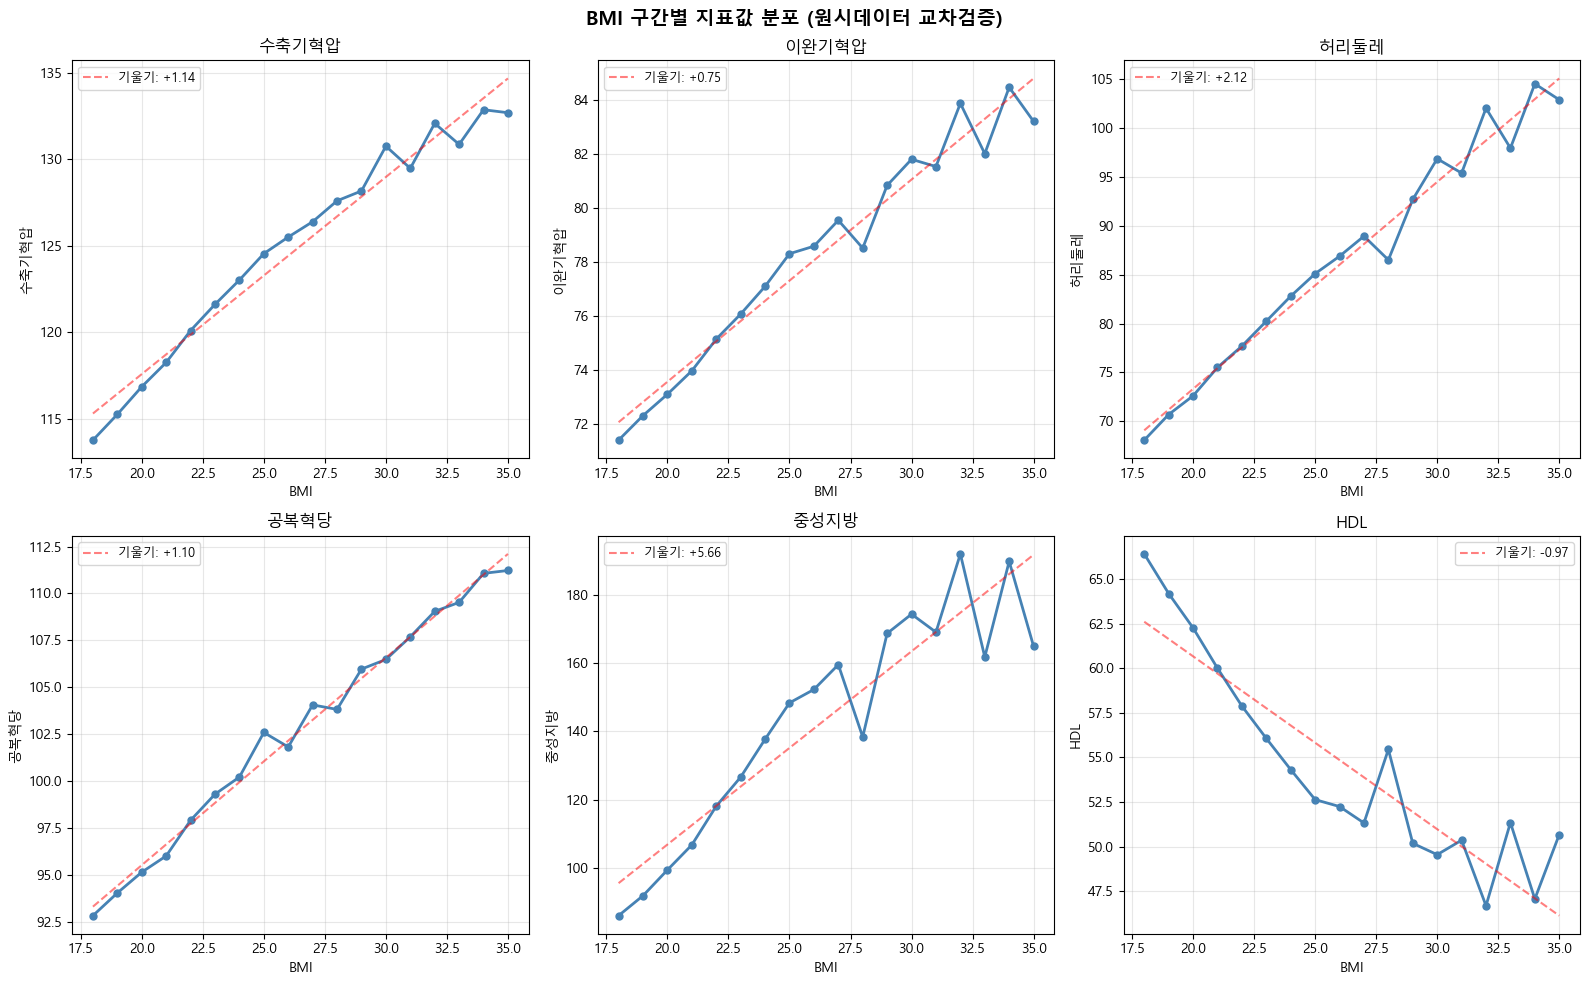


✅ 교차검증 그래프 저장: cross_validation_bmi.png


In [11]:
# STEP 10. 원시데이터 교차검증

import matplotlib.pyplot as plt  # 그래프 그리기 라이브러리
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 설정
matplotlib.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

print('=' * 65)
print('  [\uc6d0\uc2dc\ub370\uc774\ud130 \uad50\ucc28\uac80\uc99d] BMI \uad6c\uac04\ubcc4 \ud3c9\uade0 \uc9c0\ud45c\uac12 \ube44\uad50')
print('=' * 65)

bmi_ranges = [
    (18.0, 20.0, 'BMI 18-20'),  # 저체중~정상 하단
    (20.0, 22.0, 'BMI 20-22'),  # 정상
    (22.0, 24.0, 'BMI 22-24'),  # 정상 상단
    (24.0, 26.0, 'BMI 24-26'),  # 과체중 시작
    (26.0, 28.0, 'BMI 26-28'),  # 과체중
    (28.0, 30.0, 'BMI 28-30'),  # 비만 시작
    (30.0, 33.0, 'BMI 30-33'),  # 비만
    (33.0, 37.0, 'BMI 33-37'),  # 고도비만
]

cols = ['sbp','dbp','waist','bs','tg','hdl']  # 분석할 지표 컬럼명
labels = ['\uc218\ucd95\uae30\ud601\uc555','\uc774\uc644\uae30\ud601\uc555','\ud5c8\ub9ac\ub458\ub808','\uacf5\ubcf5\ud601\ub2f9','\uc911\uc131\uc9c0\ubc29','HDL']  # 한글 이름

rows = []
for lo, hi, name in bmi_ranges:
    grp = raw_df[(raw_df['bmi'] >= lo) & (raw_df['bmi'] < hi)]
    if len(grp) < 100:  # 100명 미만이면 통계적으로 의미없어서 제외
        continue
    row = {'\uad6c\uac04': name, '\uc778\uc6d0\uc218': len(grp)}
    for c in cols:
        row[c] = grp[c].mean()  # 각 지표의 평균값 계산
    rows.append(row)

df_bmi = pd.DataFrame(rows).set_index('\uad6c\uac04')
print('\n[BMI \uad6c\uac04\ubcc4 \ud3c9\uade0 \uc9c0\ud45c\uac12]')
print(df_bmi[['\uc778\uc6d0\uc218'] + cols].round(1).to_string())

print('\n' + '=' * 65)
print('  [BMI 1 \uac10\uc18c \uc2dc \ud3c9\uade0 \uc9c0\ud45c \ubcc0\ud654\ub7c9]')
print('  (\uc6d0\uc2dc\ub370\uc774\ud130 \ub2e8\uba74 \ube44\uad50 - \ubc29\ud5a5\uc131 \uac80\uc99d\uc6a9)')
print('=' * 65)

bmi_means = raw_df.copy()
bmi_means['bmi_bin'] = (bmi_means['bmi'] // 1).astype(int)  # 소수점 버리고 정수로
grp_bmi = bmi_means.groupby('bmi_bin')[cols].mean()
grp_bmi = grp_bmi[(grp_bmi.index >= 18) & (grp_bmi.index <= 35)]  # 18~35 범위만 사용

slopes = {}
for c, label in zip(cols, labels):
    x = grp_bmi.index.values.astype(float)  # BMI 값 (18,19,20,...)
    y = grp_bmi[c].values                   # 지표 평균값
    coef = np.polyfit(x, y, 1)
    slopes[c] = coef[0]  # 기울기 = BMI 1 증가 시 지표 변화량

print(f"  {'\uc9c0\ud45c':<12} {'BMI 1\u2191 \uc2dc':>10}  {'BMI 1\u2193 \uc2dc(\uac10\ub7c9\ud6a8\uacfc)':>18}  \ubc29\ud5a5")
print(f"  {'-'*55}")
for c, label in zip(cols, labels):
    s = slopes[c]
    expected = '\u2705 \uc815\uc0c1' if (c != 'hdl' and s > 0) or (c == 'hdl' and s < 0) else '\u26a0\ufe0f \ud655\uc778\ud544\uc694'
    print(f"  {label:<12} {s:>+10.3f}  {'\u2192 \uac10\ub7c9\uc2dc ' + ('\uac10\uc18c' if s>0 else '\uc99d\uac00'):>18}  {expected}")

print('\n' + '=' * 65)
print('  [\ubaa8\ub378 \uc608\uce21 vs \uc6d0\uc2dc\ub370\uc774\ud130 \ube44\uad50]')
print('  \uc870\uac74: 40\ub300 \ub0a8\uc131 / \ube44\ud761\uc5f0 / \ube44\uc74c\uc8fc / BMI 27 \u2192 25 (\uc57d 6kg \uac10\ub7c9)')
print('=' * 65)

grp_high = raw_df[
    (raw_df['bmi'] >= 26) & (raw_df['bmi'] < 28) &
    (raw_df['gender'] == 1) & (raw_df['age_code'].isin([9, 10]))
]
grp_low = raw_df[
    (raw_df['bmi'] >= 24) & (raw_df['bmi'] < 26) &
    (raw_df['gender'] == 1) & (raw_df['age_code'].isin([9, 10]))
]

raw_diff = grp_low[cols].mean() - grp_high[cols].mean()

bmi27_weight = 27 * (1.72 ** 2)
avg_stats    = grp_high[cols].mean()  # BMI 26~28 그룹의 평균 지표값

model_inp = pd.DataFrame([{
    'gender':     1, 'age_code': 10, 'height': 172.0,
    'smoke':      0, 'drink':    0,
    'weight_pre': round(bmi27_weight, 1),
    'weight_diff':6.0,           # 6kg 감량
    'waist_pre':  avg_stats['waist'],  # BMI 27 그룹 평균 허리
    'sbp_pre':    avg_stats['sbp'],    # BMI 27 그룹 평균 혈압
    'dbp_pre':    avg_stats['dbp'],
    'bs_pre':     avg_stats['bs'],
    'tg_pre':     avg_stats['tg'],
    'hdl_pre':    avg_stats['hdl'],
}]).astype('float32')

print(f'\n  \uc6d0\uc2dc\ub370\uc774\ud130 BMI 26~28 \uadf8\ub8f9 \ud3c9\uade0 (n={len(grp_high):,}\uba85)')
print(f'  {avg_stats.round(1).to_dict()}')
print(f"\n  {'\uc9c0\ud45c':<12} {'\uc6d0\uc2dc\ub370\uc774\ud130 \ucc28\uc774':>15} {'\ubaa8\ub378 \uc608\uce21 \u0394':>13}  \ud310\uc815")
print(f"  {'-'*55}")

delta_cols = ['delta_waist','delta_sbp','delta_dbp','delta_bs','delta_tg','delta_hdl']
for c, dc, label in zip(cols, delta_cols, labels):
    raw_d   = raw_diff[c]                                    # 원시데이터 차이
    model_d = float(models[dc].predict(model_inp)[0])        # 모델 예측값
    same_dir = (raw_d * model_d) > 0
    status   = '\u2705' if same_dir else '\u26a0\ufe0f'
    print(f'  {label:<12} {raw_d:>+14.2f}  {model_d:>+12.2f}  {status}')

print(f'\n  \u203b \uc6d0\uc2dc\ub370\uc774\ud130 \ucc28\uc774 = BMI 24~26 \uadf8\ub8f9 \ud3c9\uade0 - BMI 26~28 \uadf8\ub8f9 \ud3c9\uade0')
print(f'  \u203b \ubc29\ud5a5\uc774 \uc77c\uce58\ud558\uba74 \ubaa8\ub378\uc774 \uc62c\ubc14\ub978 \ud328\ud134\uc744 \ud559\uc2b5\ud55c \uac83')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('BMI \uad6c\uac04\ubcc4 \uc9c0\ud45c\uac12 \ubd84\ud3ec (\uc6d0\uc2dc\ub370\uc774\ud130 \uad50\ucc28\uac80\uc99d)', fontsize=14, fontweight='bold')

for ax, c, label in zip(axes.flat, cols, labels):
    x = grp_bmi.index.values   # X축: BMI 값
    y = grp_bmi[c].values      # Y축: 지표 평균값

    ax.plot(x, y, 'o-', color='steelblue', linewidth=2, markersize=5)
    ax.set_xlabel('BMI')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)  # 격자선 (alpha=0.3: 30% 투명도)

    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), '--', color='red', alpha=0.5, label=f'\uae30\uc6b8\uae30: {z[0]:+.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cross_validation_bmi.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n\u2705 \uad50\ucc28\uac80\uc99d \uadf8\ub798\ud504 \uc800\uc7a5: cross_validation_bmi.png')
